In [1]:
import pandas as pd

In [6]:
EUR_data = pd.read_csv('tcmb_eur_verisi_1000.csv')
df = EUR_data.copy()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1244 entries, 0 to 1243
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tarih          1244 non-null   object 
 1   Yıl            1244 non-null   int64  
 2   Ay             1244 non-null   int64  
 3   Birim          1244 non-null   object 
 4   Alış (Forex)   1244 non-null   float64
 5   Satış (Forex)  1244 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 58.4+ KB


In [10]:
df.head()

,Tarih,Yıl,Ay,Birim,Alış (Forex),Satış (Forex)
0,2020-12-07,2020,12,Euro (EUR),9.4913,9.5084
1,2020-12-08,2020,12,Euro (EUR),9.4620,9.4790
2,2020-12-09,2020,12,Euro (EUR),9.4840,9.5011
3,2020-12-10,2020,12,Euro (EUR),9.4932,9.5103
4,2020-12-11,2020,12,Euro (EUR),9.6241,9.6414


In [16]:
df['Gun'] = df['Tarih'].apply(lambda x: int(x[-2:]))
df['Gun'].head()

0     7
1     8
2     9
3    10
4    11
Name: Gun, dtype: int64

In [18]:
df.head()

,Tarih,Yıl,Ay,Birim,Alış (Forex),Satış (Forex),Gun
0,2020-12-07,2020,12,Euro (EUR),9.4913,9.5084,7
1,2020-12-08,2020,12,Euro (EUR),9.4620,9.4790,8
2,2020-12-09,2020,12,Euro (EUR),9.4840,9.5011,9
3,2020-12-10,2020,12,Euro (EUR),9.4932,9.5103,10
4,2020-12-11,2020,12,Euro (EUR),9.6241,9.6414,11


In [20]:
df['Tarih'] = pd.to_datetime(df['Tarih'])
df = df.sort_values(by = 'Tarih')
df = df.reset_index(drop=True)

In [22]:
df['Haftalik_Ortalama'] = df['Alış (Forex)'].rolling(window=7).mean()

In [24]:
df['Onceki_Gun_Fiyat'] = df['Alış (Forex)'].shift(1)

In [26]:
df.dropna(inplace = True)

In [28]:
df.reset_index(drop=True, inplace=True)

In [30]:
df.head()

,Tarih,Yıl,Ay,Birim,Alış (Forex),Satış (Forex),Gun,Haftalik_Ortalama,Onceki_Gun_Fiyat
0,2020-12-15,2020,12,Euro (EUR),9.5184,9.5355,15,9.519343,9.5624
1,2020-12-16,2020,12,Euro (EUR),9.4908,9.5079,16,9.519271,9.5184
2,2020-12-17,2020,12,Euro (EUR),9.4817,9.4988,17,9.522086,9.4908
3,2020-12-18,2020,12,Euro (EUR),9.4230,9.4400,18,9.513371,9.4817
4,2020-12-21,2020,12,Euro (EUR),9.3504,9.3672,21,9.492971,9.4230


In [32]:
df.drop(columns = 'Birim', inplace = True)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tarih              1238 non-null   datetime64[ns]
 1   Yıl                1238 non-null   int64         
 2   Ay                 1238 non-null   int64         
 3   Alış (Forex)       1238 non-null   float64       
 4   Satış (Forex)      1238 non-null   float64       
 5   Gun                1238 non-null   int64         
 6   Haftalik_Ortalama  1238 non-null   float64       
 7   Onceki_Gun_Fiyat   1238 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 77.5 KB


In [36]:
df.isna().sum()

Tarih                0
Yıl                  0
Ay                   0
Alış (Forex)         0
Satış (Forex)        0
Gun                  0
Haftalik_Ortalama    0
Onceki_Gun_Fiyat     0
dtype: int64

In [38]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex),Gun,Haftalik_Ortalama,Onceki_Gun_Fiyat
0,2020-12-15,2020,12,9.5184,9.5355,15,9.519343,9.5624
1,2020-12-16,2020,12,9.4908,9.5079,16,9.519271,9.5184
2,2020-12-17,2020,12,9.4817,9.4988,17,9.522086,9.4908
3,2020-12-18,2020,12,9.4230,9.4400,18,9.513371,9.4817
4,2020-12-21,2020,12,9.3504,9.3672,21,9.492971,9.4230


In [40]:
X = df[['Yıl', 'Ay', 'Gun', 'Onceki_Gun_Fiyat', 'Haftalik_Ortalama']]
y = df['Alış (Forex)']

In [42]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [46]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [48]:
model_configs = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {} # Linear Regression'da genelde hiperparametre aranmaz
    },
    'Ridge': {
        'model': Ridge(),
        'params': {
            'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0] # Ceza katsayısı
        }
    },
    'Lasso': {
        'model': Lasso(),
        'params': {
            'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0] # Ceza katsayısı
        }
    }
}

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [52]:
tscv = TimeSeriesSplit(n_splits=5)

results = []

print("Modeller eğitiliyor ve GridSearch yapılıyor...\n")

for model_name, config in model_configs.items():
    # Pipeline Kurulumu
    pipe = Pipeline([
        ('scaler', StandardScaler()),     # Veriyi standardize et
        ('regressor', config['model'])    # Modeli koy
    ])
    
    # GridSearch Kurulumu
    grid = GridSearchCV(
        estimator=pipe, 
        param_grid=config['params'], 
        cv=tscv,                          # Zaman serisi uyumlu CV
        scoring='neg_mean_squared_error', # Hata metriği (MSE)
        n_jobs=-1                         # Tüm işlemcileri kullan
    )
    
    # Eğit
    grid.fit(X_train, y_train)
    
    # En iyi modeli al ve test et
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Metrikleri hesapla
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"En İyi Parametreler: {grid.best_params_}")
    print(f"Test Seti RMSE: {rmse:.4f}")
    print(f"Test Seti R2 Score: {r2:.4f}\n")
    
    results.append({
        'Model': model_name,
        'Best_Model_Object': best_model,
        'RMSE': rmse,
        'R2': r2
    })

# Sonuçları karşılaştırma (En düşük RMSE en iyisidir)
results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("KAZANAN MODEL:")
print(results_df.iloc[0])

Modeller eğitiliyor ve GridSearch yapılıyor...

--- LinearRegression ---
En İyi Parametreler: {}
Test Seti RMSE: 0.2280
Test Seti R2 Score: 0.9976

--- Ridge ---
En İyi Parametreler: {'regressor__alpha': 0.01}
Test Seti RMSE: 0.2277
Test Seti R2 Score: 0.9976

--- Lasso ---
En İyi Parametreler: {'regressor__alpha': 0.001}
Test Seti RMSE: 0.2307
Test Seti R2 Score: 0.9975

KAZANAN MODEL:
Model                                                Ridge
Best_Model_Object    (StandardScaler(), Ridge(alpha=0.01))
RMSE                                              0.227679
R2                                                0.997558
Name: 1, dtype: object


In [54]:
final_best_model = results_df.iloc[0]['Best_Model_Object']

In [56]:
import joblib

# Kazanan modeli (final_best_model değişkenindeydi) kaydediyoruz
# Dosya adını projenle uyumlu verebilirsin
filename = 'EUR_Model.pkl'

joblib.dump(final_best_model, filename)

print(f"Model başarıyla '{filename}' olarak kaydedildi!")

Model başarıyla 'EUR_Model.pkl' olarak kaydedildi!


In [58]:
df.to_csv('euro_fit_veri.csv')

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

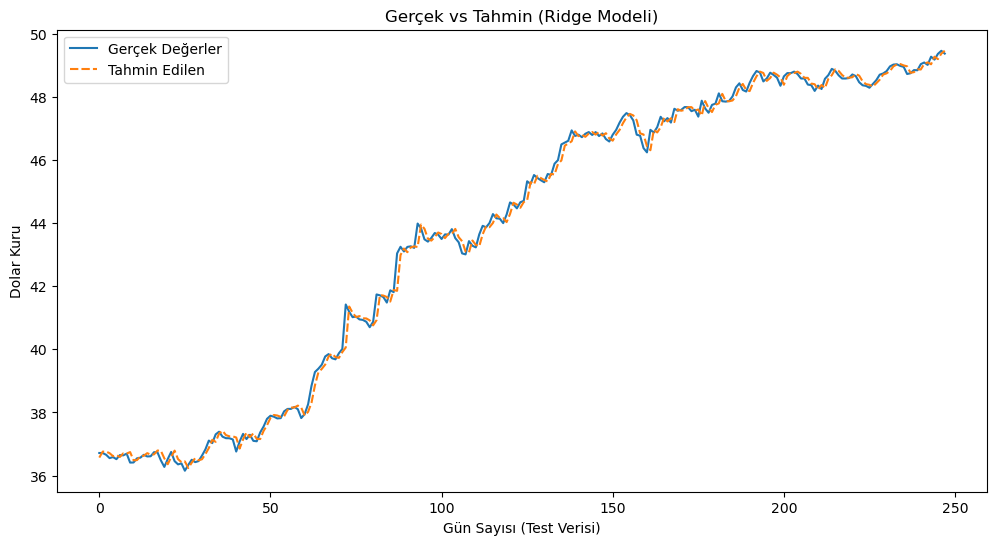

In [62]:
# 1. Tahminleri alalım
tahminler = final_best_model.predict(X_test)

# 2. Karşılaştırma DataFrame'i oluşturalım
# y_test.values diyerek indeksi çöpe atıyoruz, sadece rakamları alıyoruz.
karsilastirma = pd.DataFrame({
    'Gerçek Değerler': y_test.values,
    'Tahmin Edilen': tahminler
})

# 3. Çizdirelim
plt.figure(figsize=(12, 6))
sns.lineplot(data=karsilastirma)
plt.title('Gerçek vs Tahmin (Ridge Modeli)')
plt.ylabel('Dolar Kuru')
plt.xlabel('Gün Sayısı (Test Verisi)')
plt.show()